#### Começamos nosso projeto em virtude da importância do diagnóstico precoce como ferramenta no combate a doenças, em particular as de alta gravidade, como as do coração. Um diagnóstico precoce pode ser a difenrença entre a vida e a morte, e pra isso esse projeto foi desenvolvido: atuar no auxílio ao tratamento de doenças do coração

### Nossos dados consistem de uma base de dados extraída do Kaggle, mais específicamente, a base de Heart Disease, da competição finalizada ao fim de fevereiro (28/02/2026)

Como a base de dados não possui missings, e também não possui outliers significativos (ou seja, os dados extremos, que existem, são possíveis no mundo real) não foi feito nenhum tratamento de dados específico relativo a isso, pois o nosso modelo principal o CatboostClassifier, consegue lidar bem com essa problemática usando seus splits, ou seja, segmentando a relevância de cada variável e desprezando variações particularmente intensas. Por esse contexto, nossos feature enginering se restringiu a agrupar categorias raras que poderiam gerar ruído no nosso modelo, e considerar cada categoria corretamente, ou seja, eliminando a influência de variáveis "numéricas" que na verdade eram categóricas, já que se o modelo imputasse incorretamente o conceito de "distância" que não necessariamente existe pra tais categorias, poderiamos ter prejuízos ao modelo.

# O overview do nosso df é:

In [1]:
import pandas as pd

df=pd.read_csv('train.csv')
df.head(3)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence


Portanto, foram alteradas algumas variáveis para categorias, ou seja, sex, Chest pain type, exercise angina, ekg results, FBS over 120, Slope of ST e etc. Esse processo foi feito e salvo no .csv df_att.csv, que possui nosso df após todas essas atualizações. O mesmo encontra-se na pasta "deprecated data_results", junto com outros elementos como os folds usados na geração de OOF's.

# Quanto à correlação no df, podemos visualizar abaixo, e usaremos o df_att justamente para evitar problemas com isso.:

In [5]:
import joblib

df_att = joblib.load('df_att.pkl')

df_att.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   Age                      630000 non-null  int64   
 1   Sex                      630000 non-null  category
 2   Chest pain type          630000 non-null  category
 3   BP                       630000 non-null  int64   
 4   Cholesterol              630000 non-null  int64   
 5   FBS over 120             630000 non-null  category
 6   EKG results              630000 non-null  category
 7   Max HR                   630000 non-null  int64   
 8   Exercise angina          630000 non-null  category
 9   ST depression            630000 non-null  float64 
 10  Slope of ST              630000 non-null  category
 11  Number of vessels fluro  630000 non-null  int64   
 12  Thallium                 630000 non-null  int64   
 13  Heart Disease            630000 non-null  ob

## Como pode ser visto, o devido tratamento foi dado com relação às variáveis categóricas, e agora, para visualizar a correlação fazemos:

In [6]:
df_att.select_dtypes(include='number').corr()

,Age,BP,Cholesterol,Max HR,ST depression,Number of vessels fluro,Thallium
Age,1.000000,-0.003960,0.019485,-0.097542,0.103064,0.102758,0.150124
BP,-0.003960,1.000000,-0.004597,0.004391,-0.004024,-0.003143,-0.005884
Cholesterol,0.019485,-0.004597,1.000000,-0.048575,0.044678,0.048800,0.061817
Max HR,-0.097542,0.004391,-0.048575,1.000000,-0.229462,-0.236319,-0.306912
ST depression,0.103064,-0.004024,0.044678,-0.229462,1.000000,0.293642,0.316891
Number of vessels fluro,0.102758,-0.003143,0.048800,-0.236319,0.293642,1.000000,0.333460
Thallium,0.150124,-0.005884,0.061817,-0.306912,0.316891,0.333460,1.000000


Como nossa variável alvo tecnicamente é categórica, para visualizarmos a correlação com ela, fazemos:

In [7]:
df_att['Heart Disease'] = df_att['Heart Disease'].map({'Presence': 1, 'Absence': 0})

In [8]:
df_att.select_dtypes(include='number').corr()

,Age,BP,Cholesterol,Max HR,ST depression,Number of vessels fluro,Thallium,Heart Disease
Age,1.000000,-0.003960,0.019485,-0.097542,0.103064,0.102758,0.150124,0.212091
BP,-0.003960,1.000000,-0.004597,0.004391,-0.004024,-0.003143,-0.005884,-0.005181
Cholesterol,0.019485,-0.004597,1.000000,-0.048575,0.044678,0.048800,0.061817,0.082753
Max HR,-0.097542,0.004391,-0.048575,1.000000,-0.229462,-0.236319,-0.306912,-0.440985
ST depression,0.103064,-0.004024,0.044678,-0.229462,1.000000,0.293642,0.316891,0.430641
Number of vessels fluro,0.102758,-0.003143,0.048800,-0.236319,0.293642,1.000000,0.333460,0.438604
Thallium,0.150124,-0.005884,0.061817,-0.306912,0.316891,0.333460,1.000000,0.605776
Heart Disease,0.212091,-0.005181,0.082753,-0.440985,0.430641,0.438604,0.605776,1.000000


Vemos portanto, correlação forte entre a presença de Heart Disease e Thallium e correlação inversa com MAX HR. Vamos visualizar essa relação graficamente:

<Axes: xlabel='Thallium', ylabel='count'>

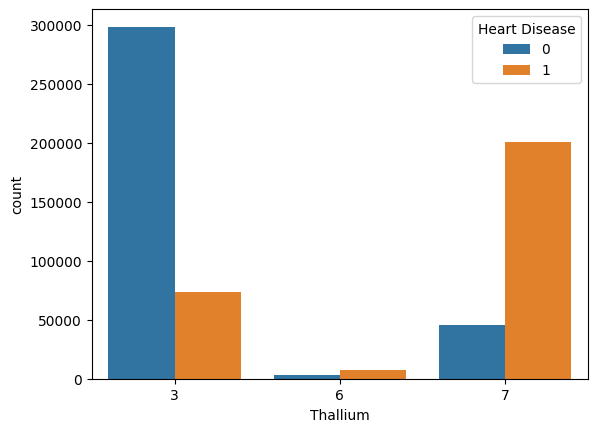

In [12]:
import seaborn as sns

sns.countplot(data=df_att, x='Thallium', hue='Heart Disease')

## Aqui podemos ver claramente uma fortíssima relação entre o Thallium 6 e 7 e nosso risco de doença cardíaca.

In [22]:
df['Heart Disease'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})
gb = df.groupby('Thallium')['Heart Disease'].mean()


In [23]:
gb

Thallium
3    0.198049
6    0.686394
7    0.815391
Name: Heart Disease, dtype: float64